* Brandon Connors
* 10/24/21
* Jupyter Notebooks - Jupyter Charts

In [40]:
import urllib3
import re
import json
import pyodbc

# Opens the credentials file I've got saved and stores the username and password in memory
with open('C:\\School\\2021 - 4 - Fall\\DA 320\\credentials.json') as f:
    data = json.load(f)
    username = data['username']
    password = data['password']

# connects to the SQL server using the credentials
conn = pyodbc.connect('Driver={SQL Server};'
                      'Server=BRANDON;'
                      'Database=DA_320;'
                      'UID=' + username + ';'
                      'PWD=' + password)

# I'm using this example code from https://zetcode.com/python/urllib3/ and tweaking it according to the feedback on the discussion boards about the security on the website.
http = urllib3.PoolManager()


# this function takes in the list of IDs and the paired list for a given field and outputs it as just a list of that field in a one-to-one match with the ID list
def parsePairedList(IDList, pairedList):
    outputList = []
    for i in range(len(IDList)):
        counter = 0
        for j in range(len(pairedList)):
            if IDList[i] == pairedList[j][0]:
                outputList.append(pairedList[j][1])
                break
            elif IDList[i] != pairedList[j][0]:
                counter += 1
            if counter == len(pairedList):
                outputList.append(None)    
    return outputList

# this function takes in the list of IDs and the paired thumbnail URL list and outputs it as just a list of the URL in a one-to-one match with the ID list (because the url is before the movie ID in the URL regex I needed to change my function)
def parsePairedURLList(IDList, pairedList):
    outputList = []
    for i in range(len(IDList)):
        counter = 0
        for j in range(len(pairedList)):
            if IDList[i] == pairedList[j][1]:
                if pairedList[j][0] != 'https://static.metacritic.com/images/products/movies/98w-movie.jpg':
                    outputList.append(pairedList[j][0])
                    break
                else:
                    outputList.append(None)
                    break
            elif IDList[i] != pairedList[j][1]:
                counter += 1
            if counter == len(pairedList):
                outputList.append(None)    
    return outputList

# for loop to cycle through a range of years
for year in range(1999,2010):
    print(f"Scraping the information for {year}.")
    page = 0
    # while loop continues through the pages of each year until it hits 0 movie IDs (which will trigger a retry, but if it hits attempts done then it will move on to the next page)
    while True:
        print(f"Currently looking at page {page} of the year {year}.")
        
        # Website I'm currently scraping from.
        website = str("https://www.metacritic.com/browse/movies/score/metascore/year/filtered?year_selected=" + str(year) + "&sort=desc&view=detailed&page=" + str(page))
        
        # this initializes a variable that will be used to count retries if a page fails to load properly
        tryCounter = 1
        
        
        while tryCounter <= 3:
             
            # This line fakes a web browser to circumvent the security on Metacritic - This was found on stackoverflow by Sav Bell and shared with the discussion board
            resp = http.request('GET', website, headers={'User-Agent': 'Mozilla/5.0'})
        
            # This decodes the result from the request above using utf-8
            text = resp.data.decode('utf-8')
        
            # Here I am searching for the regex strings and assigning the results to lists. These regex statements find pairs of IDs and their associated data, this is to make sure each 
            metacriticIDs = re.findall('<input type=\"checkbox\" id=\"(.*?)\" class=\"clamp-summary-expand\"', text)
            # The thumbnail URL regex is different from the other pairing regex because the thumbnail comes before the ID.
            IDThumbnailURLPairs = re.findall('<tr>(?:[\s\S]*?<a href=\"\/movie\/.*\"><img src=\")(?:(?P<ThumbnailURL>.*?)\" alt=\")(?:[\s\S]*?<input type=\"checkbox\" id=\")(?:(?P<MetacriticID>.*?)\" class=\"clamp-summary-expand\")[\s\S]*?<\/tr>', text)
            IDTitlePairs = re.findall('<tr>(?:[\s\S]*?<input type=\"checkbox\" id=\")(?:(?P<MetacriticID>.*?)\" class=\"clamp-summary-expand\")(?:[\s\S]*?class=\"title\"><h3>)(?:(?P<Titles>.*?)<\/h3><\/a>)[\s\S]*?<\/tr>', text)
            IDReleaseDatePairs = re.findall('<tr>(?:[\s\S]*?<input type=\"checkbox\" id=\")(?:(?P<MetacriticID>.*?)\" class=\"clamp-summary-expand\")(?:[\s\S]*?<div class=\"clamp-details\">\n+\s+<span>)(?:(?P<ReleaseDates>.*?)<\/span>)[\s\S]*?<\/tr>', text)
            # the description regex uses a flag to make sure that any newline characters in a description are also captured. 
            # I had an issue where one of the pages returned fewer than the expected number of descriptions and I realized it was because one of them contained a newline character. 
            # This also caused the regex to inaccurately capture the descriptions after that point, no longer correctly tying it to the ID
            IDDescriptionPairs = re.findall('<tr>(?:[\s\S]*?<input type=\"checkbox\" id=\")(?:(?P<MetacriticID>.*?)\" class=\"clamp-summary-expand\")(?:[\s\S]*?<div class=\"summary\">\n\s+)(?:(?P<Description>.*?)\n\s+<\/div>)[\s\S]*?<\/tr>', text, re.S)
            IDMetacriticScorePairs = re.findall('<tr>(?:[\s\S]*?<input type=\"checkbox\" id=\")(?:(?P<MetacriticID>.*?)\" class=\"clamp-summary-expand\")(?:[\s\S]*?<span class=\"title\">Metascore:<\/span>\n\s+<a class=\"metascore_anchor\" href=\"\/movie\/.+\/critic.+\n<div class.+\">)(?:(?P<MetacriticScores>.*?)<\/div>)[\s\S]*?<\/tr>', text)
            IDUserScorePairs = re.findall('<tr>(?:[\s\S]*?<input type=\"checkbox\" id=\")(?:(?P<MetacriticID>.*?)\" class=\"clamp-summary-expand\")(?:[\s\S]*?<a class=\"metascore_anchor\" href=\"\/movie\/.+\/user.+\n<div class.+\">)(?:(?P<UserScore>.*?)<\/div>)[\s\S]*?<\/tr>', text)
            IDRatingPairs = re.findall('<tr>(?:[\s\S]*?<input type=\"checkbox\" id=\")(?:(?P<MetacriticID>.*?)\" class=\"clamp-summary-expand\")(?:[\s\S]*?<span class=\"cert_rating )(?:(?P<Rating>.*?)\">)[\s\S]*?<\/tr>', text)

            # this checks to see if the attempt returned any results or not
            if len(metacriticIDs) == 0:
                # if no results returned, increment try number until 3 total attempts have been made, then move on
                if tryCounter < 3:
                    tryCounter += 1
                    print(f'Retrying page {page} of year {year}, attempt #{tryCounter}')
                    continue
                elif tryCounter >= 3:
                    print(f'Either it did not work at all OR it is done, either way, moving on to the next page')
                    break
            # if there were results, parse the ID-field pairs and commit the parsed results to the database
            else:
                print(f'Found {len(metacriticIDs)} results, parsing and then committing to database')
                movieTitles = parsePairedList(metacriticIDs, IDTitlePairs)
                releaseDates = parsePairedList(metacriticIDs, IDReleaseDatePairs)
                movieRatings = parsePairedList(metacriticIDs, IDRatingPairs)
                metacriticScores = parsePairedList(metacriticIDs, IDMetacriticScorePairs)
                userScores = parsePairedList(metacriticIDs, IDUserScorePairs)
                thumbnailURLs = parsePairedURLList(metacriticIDs, IDThumbnailURLPairs)
                movieDescriptions = parsePairedList(metacriticIDs, IDDescriptionPairs)
                # Sanity check here to make sure I caught everything
#                print('IDs:', len(metacriticIDs), '\nID-Title', len(IDTitlePairs), '\t\tTitles:', len(movieTitles), '\nID-Dates', len(IDReleaseDatePairs), '\t\tDates:', len(releaseDates), '\nID-Descriptions', len(IDDescriptionPairs), '\tDescriptions:', len(movieDescriptions), 
#                      '\nID-MScores', len(IDMetacriticScorePairs), '\t\tMScores:', len(metacriticScores), '\nID-URL', len(IDThumbnailURLPairs), '\t\tURLs:', len(thumbnailURLs), '\nID-UScores', len(IDUserScorePairs), '\t\tUScores:', len(userScores), '\nID-Rating:', len(IDRatingPairs), '\t\tRatings:', len(movieRatings))

                # Copied this part from the lecture notes - uses SQL commands to insert data pulled from Metacritic into SQL database
                cursor = conn.cursor()
                sql = "INSERT INTO Movies (MetacriticID, Title, ReleaseDate, Rating, MetacriticScore, UserScore, ThumbnailURL, Description) values (?, ?, ?, ?, ?, ?, ?, ?)"
                args = "MetacriticID", "Title", "ReleaseDate", "Rating", "MetacriticScore", "UserScore", "ThumbnailURL", "Description"

                # For Loop to iterate through all the items and insert them into the appropriate spot in the database
                for i in range(len(metacriticIDs)):
                    args = metacriticIDs[i], movieTitles[i], releaseDates[i], movieRatings[i], metacriticScores[i], userScores[i], thumbnailURLs[i], movieDescriptions[i]
                    cursor.execute(sql,args)
                    cursor.commit()
                print(f'Done committing page {page} of year {year} to SQL server')
                # increments page counter
                page += 1
                break


        
        if len(metacriticIDs) == 0:
            print(f'Done with year {year}')
            break
        
        
        

Scraping the information for 1999.
Currently looking at page 0 of the year 1999.
Found 100 results, parsing and then committing to database
Done committing page 0 of year 1999 to SQL server
Currently looking at page 1 of the year 1999.
Found 100 results, parsing and then committing to database
Done committing page 1 of year 1999 to SQL server
Currently looking at page 2 of the year 1999.
Found 54 results, parsing and then committing to database
Done committing page 2 of year 1999 to SQL server
Currently looking at page 3 of the year 1999.
Retrying page 3 of year 1999, attempt #2
Retrying page 3 of year 1999, attempt #3
Either it did not work at all OR it is done, either way, moving on to the next page
Done with year 1999
Scraping the information for 2000.
Currently looking at page 0 of the year 2000.
Found 100 results, parsing and then committing to database
Done committing page 0 of year 2000 to SQL server
Currently looking at page 1 of the year 2000.
Found 100 results, parsing and th

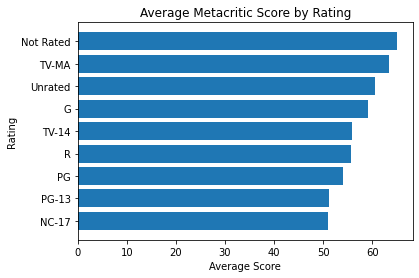

In [58]:
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

cursor = conn.cursor()
sqlImport = "SELECT Rating, ROUND(AVG(CAST(MetacriticScore AS money)),2) AS 'Average Score' FROM Movies WHERE Rating IS NOT NULL GROUP BY Rating HAVING COUNT(rating) > 10 ORDER BY 'Average Score' ASC"
cursor.execute(sqlImport)
rows = cursor.fetchall()
df = pd.DataFrame([[xy for xy in x] for x in rows])
#rint(rows)

x=df[0]
y=df[1]


plt.xlabel('Average Score')
plt.ylabel('Rating')
plt.title('Average Metacritic Score by Rating')
plt.barh(x,y)
plt.show()


The chart above plots the average Metacritic score for each rating group found. This excludes any rating groups that had fewer than 10 titles.

Also, Metacritic's site only lists titles with 7 more more reviews, so the data is not exhaustive.